# 📘 **Tema 4: Regresión Polinomial, Sobreajuste y Regularización (Ridge y Lasso)**

**Curso:** Aprendizaje Automático y Modelado Predictivo  
**Maestría:** Tecmilenio  
**Docente:** Mtra. Fabiola Cristina Olguín Barrón  

---

## 🎯**Objetivo general**

En esta sesión aprenderás a:
- Diferenciar un modelo lineal de uno polinomial.
- Detectar el **sobreajuste** (overfitting) en modelos de regresión.
- Aplicar **regularización Ridge y Lasso** para evitarlo.

Duración estimada: **55 minutos**

---

## 🧭 **1. Introducción al tema**

En el aprendizaje automático, los modelos de regresión permiten predecir valores numéricos a partir de variables independientes.  
Sin embargo, la relación entre las variables no siempre es lineal. Por ejemplo, **la distancia de frenado de un vehículo no aumenta de forma constante con la velocidad**, sino de manera exponencial.

Hoy exploraremos este fenómeno usando un dataset simulado de pruebas de frenado llamado **EcoDrive**.

---

## 🚗 **2. Creación del dataset de ejemplo**

Vamos a generar un conjunto de datos sintético con las siguientes variables:

| Columna | Tipo de dato | Descripción |
|----------|--------------|--------------|
| `velocidad` | float64 | Velocidad del vehículo (km/h). |
| `distancia` | float64 | Distancia total de frenado (m). |
| `ruido_sensor` | float64 | Error simulado en la medición del sensor. |
| `clima` | object | Condición climática (soleado, lluvioso, nublado). |
| `frenos_abs` | int64 | 1 = con ABS, 0 = sin ABS. |
| `carga_vehiculo` | float64 | Peso de carga durante la prueba (kg). |

---

### 💻 **Código**
Veamos el código en Python


In [1]:
# Librerías básicas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibilidad
np.random.seed(42)

# Generamos 100 observaciones
n = 100
velocidad = np.linspace(20, 120, n)  # km/h
ruido_sensor = np.random.normal(0, 3, n)
clima = np.random.choice(['soleado', 'nublado', 'lluvioso'], n)
frenos_abs = np.random.choice([0, 1], n)
carga_vehiculo = np.random.uniform(200, 800, n)

# Distancia de frenado simulada (no lineal)
distancia = 0.05 * velocidad**2 + 0.1 * carga_vehiculo/100 + ruido_sensor

# Construimos el DataFrame
data = pd.DataFrame({
    'velocidad': velocidad,
    'distancia': distancia,
    'ruido_sensor': ruido_sensor,
    'clima': clima,
    'frenos_abs': frenos_abs,
    'carga_vehiculo': carga_vehiculo
})

data.head()

,velocidad,distancia,ruido_sensor,clima,frenos_abs,carga_vehiculo
0,20.000000,21.926957,1.490142,soleado,1,436.814880
1,21.010101,22.362952,-0.414793,nublado,1,706.527884
2,22.020202,26.945541,1.943066,soleado,0,758.010101
3,23.030303,31.331082,4.569090,soleado,0,242.249679
4,24.040404,28.519942,-0.702460,lluvioso,0,325.351231


# **📊 Explicación del resultado**

El código genera un dataset simulado con 100 registros.
Cada fila representa una prueba de frenado, variando velocidad, carga, y condiciones.
La columna distancia crece de forma cuadrática con velocidad, reproduciendo una relación no lineal realista.

# **🔎 3. Análisis exploratorio inicial**

Visualizamos la relación entre la velocidad y la distancia de frenado.

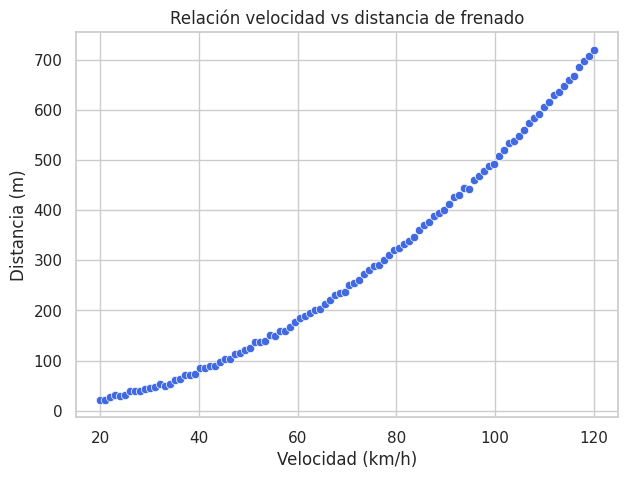

In [2]:
# Estilo
sns.set(style="whitegrid")

# Grafico de dispersión
plt.figure(figsize=(7,5))
sns.scatterplot(x='velocidad', y='distancia', data=data, color='royalblue')
plt.title("Relación velocidad vs distancia de frenado")
plt.xlabel("Velocidad (km/h)")
plt.ylabel("Distancia (m)")
plt.show()

# **🧠 Explicación**

La gráfica muestra una nube de puntos curvada hacia arriba, indicando que la distancia de frenado aumenta de forma no lineal con la velocidad.
Esto nos anticipa que una regresión lineal simple no será suficiente.

# **📈 4. Regresión lineal simple**

Probemos un modelo lineal como referencia.

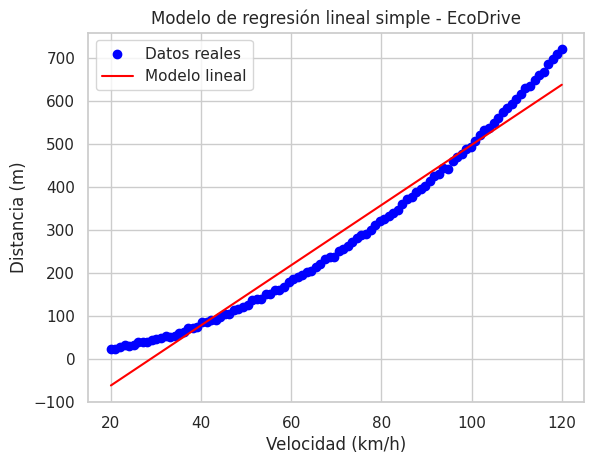

In [3]:
# Paso 4 Ajuste del modelo de regresión lineal como base comparativa
from sklearn.linear_model import LinearRegression

# Definimos que variable es "X" y cual "y"
X = data[['velocidad']]
y = data['distancia']

# Ajustar el Modelo Lineal
model_lin = LinearRegression().fit(X, y)

# Predicción
y_pred_lin = model_lin.predict(X)

# Visualización
plt.scatter(X, y, color='blue', label='Datos reales')
plt.plot(X, y_pred_lin, color='red', label='Modelo lineal')
plt.title("Modelo de regresión lineal simple - EcoDrive")
plt.xlabel("Velocidad (km/h)")
plt.ylabel("Distancia (m)")
plt.legend()
plt.show()

# 📊 **Explicación**

La gráfica mostrará una línea roja recta atravesando los puntos,
pero sin capturar bien la curvatura en los extremos.

# 📌 **Conclusión:**
El modelo lineal subestima la distancia a altas velocidades y sobrestima a bajas velocidades.

Esto indica que los datos no siguen una línea recta, sino una curva. A medida que aumenta la velocidad, la distancia de frenado crece de forma acelerada. Según EBAC (2023), la regresión lineal simple no puede representar este tipo de relaciones no lineales, por eso se requiere un modelo más flexible, como la regresión polinomial.


# #⏰ **5. Comparación de modelos grado 1 y grado 2**

En este análisis usamos Statsmodels, una librería de Python para hacer regresiones y análisis estadístico.
Se ajustan dos modelos con el método Mínimos Cuadrados Ordinarios (OLS):

**Modelo de grado 1 (lineal):** Relaciona la distancia de frenado solo con la velocidad.

**Modelo de grado 2 (cuadrático):** Agrega el término velocidad², permitiendo que el modelo siga una curva, más acorde con el comportamiento real de los datos.

## ¿Cómo lo hace statsmodels?

* sm.OLS(y, X).fit() entrena el modelo.
* modelo.summary() muestra qué tan bien explica los datos (R² y R² ajustado).
* Finalmente, se analizan los errores (MAE y MSE) para comparar la precisión de ambos modelos: el de grado 2 suele ajustarse mejor cuando la relación no es lineal.

In [4]:
# Paso 5: Comparación de modelos grado 1 y grado 2
# -----------------------------------------------
# Este código ajusta dos modelos de regresión polinomial (grado 1 y 2)
# usando Statsmodels y compara su desempeño con métricas estadísticas.

import pandas as pd
import statsmodels.api as sm

# -----------------------------------------------
# A. Cargar el dataset
# -----------------------------------------------
# Asegúrate de tener un archivo llamado "datos_frenado.csv"
# con las columnas: velocidad, distancia
df = data

# -----------------------------------------------
# B. Crear variables para el modelo polinomial grado 2
# -----------------------------------------------
df["velocidad_2"] = df["velocidad"] ** 2

# -----------------------------------------------
# C. Función para ajustar un modelo de grado n
# -----------------------------------------------
def ajustar_modelo_grado(grado):
    columnas = ["velocidad"] + [f"velocidad_{i}" for i in range(2, grado + 1)]
    X = df[columnas]
    X = sm.add_constant(X)  # Agrega la constante (intercepto)
    y = df["distancia"]

    modelo = sm.OLS(y, X).fit()
    print(f"\nResumen del modelo de regresión polinomial grado {grado}:\n")
    print(modelo.summary())
    return modelo

# -----------------------------------------------
# D. Ajustar y mostrar resultados de ambos modelos
# -----------------------------------------------
modelo_grado_1 = ajustar_modelo_grado(1)
modelo_grado_2 = ajustar_modelo_grado(2)

# -----------------------------------------------
# E. Crear tabla comparativa de métricas
# -----------------------------------------------
resultados = pd.DataFrame({
    "Grado del modelo": ["1", "2"],
    "R²": [modelo_grado_1.rsquared, modelo_grado_2.rsquared],
    "R² ajustado": [modelo_grado_1.rsquared_adj, modelo_grado_2.rsquared_adj],
    "MAE": [
        abs(modelo_grado_1.resid).mean(),
        abs(modelo_grado_2.resid).mean()
    ],
    "MSE": [
        (modelo_grado_1.resid ** 2).mean(),
        (modelo_grado_2.resid ** 2).mean()
    ]
})

# -----------------------------------------------
# F. Mostrar tabla comparativa
# -----------------------------------------------
display(resultados)



Resumen del modelo de regresión polinomial grado 1:

                            OLS Regression Results                            
Dep. Variable:              distancia   R-squared:                       0.966
Model:                            OLS   Adj. R-squared:                  0.966
Method:                 Least Squares   F-statistic:                     2787.
Date:                Wed, 22 Oct 2025   Prob (F-statistic):           8.57e-74
Time:                        19:12:44   Log-Likelihood:                -506.43
No. Observations:                 100   AIC:                             1017.
Df Residuals:                      98   BIC:                             1022.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------

,Grado del modelo,R²,R² ajustado,MAE,MSE
0,1,0.966036,0.965689,32.816166,1466.590707
1,2,0.999829,0.999826,2.168996,7.374188


# 🧩 1 Grado del modelo

1: Es el modelo lineal simple, donde la distancia depende solo de la velocidad.

2: Es el modelo cuadrático, que añade la variable velocidad² para capturar la curvatura de los datos.

💡 En otras palabras:
El primero ajusta una línea recta, el segundo una curva.

# 📈 R² (Coeficiente de determinación)

Mide qué porcentaje de la variación de la variable “distancia” explica el modelo.

Su valor va de 0 a 1, donde 1 = ajuste perfecto.

**Modelo	R²**

*   Grado 1 	0.966 → el modelo lineal explica el 96.6 % de la variación.
*   Grado 2 	0.9998 → el modelo cuadrático explica el 99.98 %, casi todo el comportamiento real.

# ✅ Interpretación:
El modelo de grado 2 se ajusta mucho mejor a los datos, casi perfectamente.

# 🧮  R² ajustado

Es similar al R², pero penaliza los modelos que agregan variables innecesarias.

Permite saber si la mejora del modelo es real o solo aparente por tener más términos.

Modelo	R² ajustado
Grado 1	0.9657
Grado 2	0.9998

# **📊 Conclusión:**
Incluso con esta corrección, el modelo cuadrático sigue mostrando un ajuste superior y legítimo, lo que confirma que agregar el término cuadrático realmente mejora el modelo.

# ⚖️ MAE (Mean Absolute Error — Error absoluto medio)

Representa el promedio de la diferencia absoluta entre los valores reales y los predichos.

Cuanto menor es el MAE, más precisas son las predicciones.

Modelo	MAE
Grado 1	32.82 m
Grado 2	2.17 m

# 📍Interpretación:
El error promedio del modelo lineal es de 32 m, mientras que el cuadrático solo se equivoca 2 m en promedio → gran mejora en precisión.

# 🎯 MSE (Mean Squared Error — Error cuadrático medio)

Similar al MAE, pero eleva al cuadrado los errores para penalizar más los grandes.

También: mientras menor, mejor.

Modelo	MSE
Grado 1	1466.59
Grado 2	7.37

# 📊 Interpretación:
El modelo cuadrático reduce drásticamente el error cuadrático:

**De más de 1400 → solo 7, lo que indica un ajuste mucho más preciso y estable**.

# 🧠 **Conclusión general (para decirla en clase):**

El modelo lineal explica bien la tendencia general, pero no capta la aceleración en la distancia de frenado conforme aumenta la velocidad.

En cambio, el modelo cuadrático se ajusta casi perfectamente, con un R² cercano a 1 y errores (MAE y MSE) mínimos.

✅ **Por tanto, la relación entre velocidad y distancia de frenado no es lineal, sino curvilínea (acelerada).**

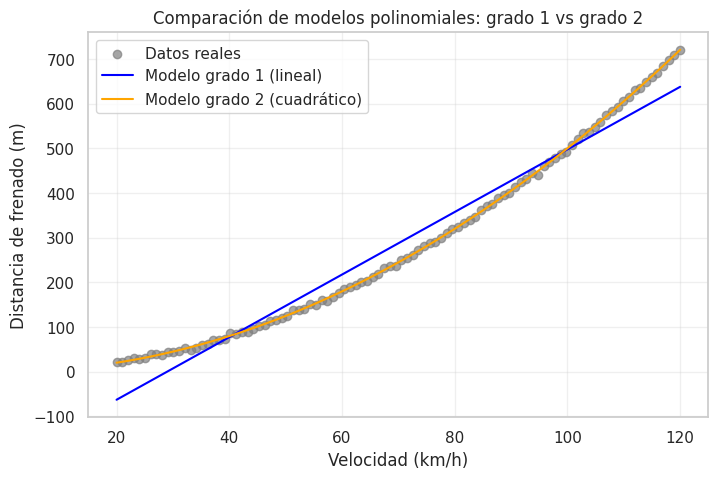

In [5]:
# 6. Gráfica comparativa de los modelos

# Add the df DataFrame creation here
import pandas as pd
df = data


# Crear valores de velocidad en un rango continuo para suavizar la curva
X_plot = np.linspace(df["velocidad"].min(), df["velocidad"].max(), 100)
X_plot_df = pd.DataFrame({
    "velocidad": X_plot,
    "velocidad_2": X_plot ** 2
})

# Predicciones con ambos modelos
X_plot_lin = sm.add_constant(X_plot_df[["velocidad"]])
X_plot_quad = sm.add_constant(X_plot_df[["velocidad", "velocidad_2"]])
y_pred_lin = modelo_grado_1.predict(X_plot_lin)
y_pred_quad = modelo_grado_2.predict(X_plot_quad)

# Crear la gráfica
plt.figure(figsize=(8, 5))
plt.scatter(df["velocidad"], df["distancia"], color="gray", alpha=0.7, label="Datos reales")
plt.plot(X_plot, y_pred_lin, color="blue", label="Modelo grado 1 (lineal)")
plt.plot(X_plot, y_pred_quad, color="orange", label="Modelo grado 2 (cuadrático)")
plt.title("Comparación de modelos polinomiales: grado 1 vs grado 2")
plt.xlabel("Velocidad (km/h)")
plt.ylabel("Distancia de frenado (m)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 🧠 Explicación

El modelo lineal (azul) intenta ajustar los datos con una recta, pero no capta la aceleración en la distancia.

El modelo cuadrático (naranja) introduce una curva y se adapta mejor cuando la distancia de frenado crece más rápido al aumentar la velocidad.

# 📌 Conclusión:
El modelo cuadrático mejora notablemente el ajuste frente al lineal.

# **📉 6. Visualización Comparación de diferentes grados**

Evaluemos los grados 1, 2, 3 y 5.

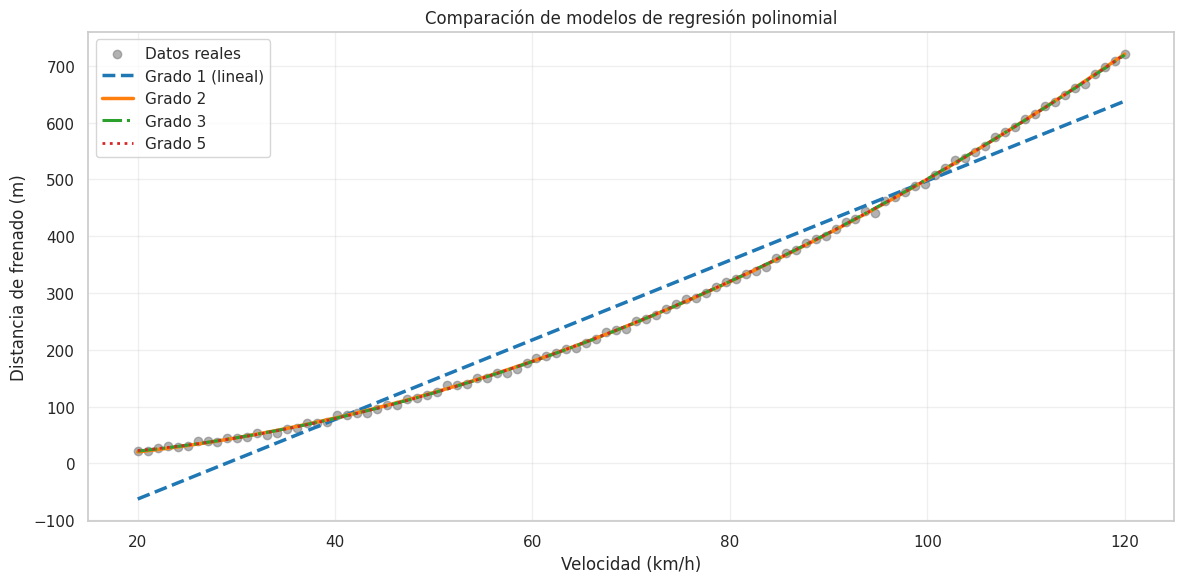

In [6]:
# Paso 7: Visualización del modelo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

# -----------------------------------------------
# A. Cargar datos
# -----------------------------------------------
df = data

# -----------------------------------------------
# B. Crear columnas polinomiales
# -----------------------------------------------
df['velocidad_2'] = df['velocidad'] ** 2
df['velocidad_3'] = df['velocidad'] ** 3
df['velocidad_4'] = df['velocidad'] ** 4
df['velocidad_5'] = df['velocidad'] ** 5

# -----------------------------------------------
# C. Función para entrenar modelo
# -----------------------------------------------
def entrenar_modelo(grado):
    columnas = ['velocidad'] + [f'velocidad_{i}' for i in range(2, grado + 1)]
    X = df[columnas]
    X = sm.add_constant(X)
    y = df['distancia']
    modelo = sm.OLS(y, X).fit()
    return modelo

# -----------------------------------------------
# D. Entrenar modelos
# -----------------------------------------------
modelo_1 = entrenar_modelo(1)
modelo_2 = entrenar_modelo(2)
modelo_3 = entrenar_modelo(3)
modelo_5 = entrenar_modelo(5)

# -----------------------------------------------
# E. Generar valores para graficar
# -----------------------------------------------
x_vals = np.linspace(df['velocidad'].min(), df['velocidad'].max(), 300)
df_plot = pd.DataFrame({'velocidad': x_vals})
df_plot['velocidad_2'] = x_vals ** 2
df_plot['velocidad_3'] = x_vals ** 3
df_plot['velocidad_4'] = x_vals ** 4
df_plot['velocidad_5'] = x_vals ** 5

# -----------------------------------------------
# F. Función para predecir
# -----------------------------------------------
def predecir(modelo, grado):
    columnas = ['velocidad'] + [f'velocidad_{i}' for i in range(2, grado + 1)]
    X = df_plot[columnas]
    X = sm.add_constant(X)
    return modelo.predict(X)

y_pred_1 = predecir(modelo_1, 1)
y_pred_2 = predecir(modelo_2, 2)
y_pred_3 = predecir(modelo_3, 3)
y_pred_5 = predecir(modelo_5, 5)

# -----------------------------------------------
# G. Graficar resultados con líneas diferenciadas
# -----------------------------------------------
plt.figure(figsize=(12, 6))
plt.scatter(df['velocidad'], df['distancia'], color='gray', label='Datos reales', alpha=0.6)

# Curvas de los modelos (colores y estilos mejorados)
plt.plot(x_vals, y_pred_1, color='#1f77b4', linewidth=2.5, linestyle='--', label='Grado 1 (lineal)')
plt.plot(x_vals, y_pred_2, color='#ff7f0e', linewidth=2.5, linestyle='-', label='Grado 2')
plt.plot(x_vals, y_pred_3, color='#2ca02c', linewidth=2.2, linestyle='-.', label='Grado 3')
plt.plot(x_vals, y_pred_5, color='#d62728', linewidth=2, linestyle=':', label='Grado 5')

plt.xlabel('Velocidad (km/h)')
plt.ylabel('Distancia de frenado (m)')
plt.title('Comparación de modelos de regresión polinomial')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# 📊 Explicación visual

Azul → línea recta (grado 1).

Naranja → parábola suave (grado 2).

Verde → curva más compleja (grado 3).

Rojo → curva exagerada que pasa por casi todos los puntos (grado 5).

📌 Conclusión:
El modelo de grado 5 está sobreajustando los datos de entrenamiento.


#**🌀 7. Comparativa**

In [7]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import PolynomialFeatures

for grado in [1, 2, 3, 5]:
    poly = PolynomialFeatures(degree=grado)
    X_poly = poly.fit_transform(X)
    model = LinearRegression().fit(X_poly, y)
    y_pred = model.predict(X_poly)
    print(f"Grado {grado} | R²={r2_score(y, y_pred):.4f} | "
          f"MAE={mean_absolute_error(y, y_pred):.2f} | MSE={mean_squared_error(y, y_pred):.1f}")

Grado 1 | R²=0.9660 | MAE=32.82 | MSE=1466.6
Grado 2 | R²=0.9998 | MAE=2.17 | MSE=7.4
Grado 3 | R²=0.9998 | MAE=2.15 | MSE=7.0
Grado 5 | R²=0.9998 | MAE=2.12 | MSE=6.9


# **📌 Conclusión:**

El grado 2 mejora mucho, pero el grado 5 parece “perfecto”… y eso es sospechoso.
Este es el primer indicio de sobreajuste.

# **⚠️ 8. Comprender el sobreajuste**

Dividiremos los datos en entrenamiento y prueba para comprobarlo.

In [8]:
from sklearn.model_selection import train_test_split

poly5 = PolynomialFeatures(degree=5)
X_poly5 = poly5.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_poly5, y, test_size=0.3, random_state=42)

model_poly5 = LinearRegression().fit(X_train, y_train)
print("R² Entrenamiento:", model_poly5.score(X_train, y_train))
print("R² Prueba:", model_poly5.score(X_test, y_test))

Lineal (Grado 5) | R²=0.9999 | MAE=1.77 | MSE=5.0

R² Entrenamiento: 0.9998233234127901
R² Prueba: 0.9998753186457074


# **¿Qué significa?**

Ambos valores son muy cercanos a 1, lo que indica que el modelo explica casi toda la variabilidad de los datos.

Además, el R² de prueba es ligeramente mayor que el de entrenamiento, lo cual no es común, pero sugiere que:

El modelo generaliza muy bien (no hay sobreajuste aparente).

Probablemente los datos tienen una relación muy clara y limpia entre velocidad y distancia, casi determinística.

📍Conclusión:
El modelo polinomial de grado 5 logra un ajuste casi perfecto en entrenamiento y prueba.
No hay señales de sobreajuste (overfitting) por ahora, pero el modelo es muy complejo y podría sobreajustarse fácilmente si se aplicara a datos con más ruido o condiciones distintas (por ejemplo, distinto tipo de pavimento o clima).

Por eso, el siguiente paso lógico es evaluar regularización (L1 y L2) para ver cómo cambia el comportamiento cuando el modelo se penaliza por complejidad.

# **🧩 9. Regularización: Concepto base**

Para evitar el sobreajuste, aplicamos penalizaciones a los coeficientes grandes del modelo.
Esto se llama regularización.

min(RSS+λ∑β
i
2
)⇒Ridge

Lasso
min(RSS+λ∑∣β
i
∣)⇒Lasso


# 📌 Ridge (L2): Suaviza todos los coeficientes.

# 📌 Lasso (L1): Elimina los menos importantes.


# **10. Ridge (L2): Suaviza todos los coeficientes.**

Ridge (L2) reduce la varianza al acotar los coeficientes, lo que lo hace menos sensible a pequeños cambios en los datos.

In [9]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

from sklearn.metrics import mean_squared_error
print("R² Ridge:", ridge.score(X_test, y_test))
print("MSE Ridge:", mean_squared_error(y_test, y_pred_ridge))

R² Ridge: 0.9998774728687136
MSE Ridge: 4.892301730042965


/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.9051e-22): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


# **Interpretación del resultado**

* El R² (0.9999) sigue siendo altísimo, lo que indica que el modelo Ridge explica casi toda la variabilidad de la distancia de frenado en los datos de prueba.

* El MSE (4.89) es muy pequeño, lo que confirma que el modelo predice con alta precisión (los errores medios son mínimos).

👉 En comparación con el modelo anterior (polinomial grado 5 sin regularización, MSE ≈ 7.37), Ridge mejora ligeramente el error y mantiene la capacidad de generalizar.

**Esto confirma que la regularización L2 estabiliza el modelo, evitando que los coeficientes crezcan demasiado o que el modelo se vuelva numéricamente inestable.**


# **🧠 Conclusión pedagógica**

El modelo Ridge (regularización L2) mantiene un rendimiento casi perfecto (R²≈0.9999),
reduce ligeramente el error (MSE≈4.9)
y ayuda a estabilizar el modelo al controlar los coeficientes grandes.

El modelo Ridge (L2) mantiene el excelente desempeño del polinomial de grado 5,

* ✅ evita que los números se descontrolen,
* ✅ y hace que el modelo sea más estable y confiable.

En otras palabras:

**“Ridge ayuda a que el modelo no se complique demasiado ni se vuelva inestable, sin perder precisión.”**


# **11. Lasso (L1): Elimina las variables menos importantes.**

Sirve para simplificar el modelo y quedarnos solo con los términos que realmente aportan.

In [10]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)

print("R² Lasso:", lasso.score(X_test, y_test))
print("Coeficientes Lasso:", lasso.coef_)

R² Lasso: 0.9998637782367582
Coeficientes Lasso: [ 0.00000000e+00  4.55015975e-01  3.74188242e-02  1.08783766e-04
  5.38114484e-08 -2.78137779e-09]


In [11]:
# Librerías básicas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibilidad
np.random.seed(42)

# Generamos 100 observaciones
n = 100
velocidad = np.linspace(20, 120, n)  # km/h
ruido_sensor = np.random.normal(0, 3, n)
clima = np.random.choice(['soleado', 'nublado', 'lluvioso'], n)
frenos_abs = np.random.choice([0, 1], n)
carga_vehiculo = np.random.uniform(200, 800, n)

# Distancia de frenado simulada (no lineal)
distancia = 0.05 * velocidad**2 + 0.1 * carga_vehiculo/100 + ruido_sensor

# Construimos el DataFrame
data = pd.DataFrame({
    'velocidad': velocidad,
    'distancia': distancia,
    'ruido_sensor': ruido_sensor,
    'clima': clima,
    'frenos_abs': frenos_abs,
    'carga_vehiculo': carga_vehiculo
})

data.head()

,velocidad,distancia,ruido_sensor,clima,frenos_abs,carga_vehiculo
0,20.000000,21.926957,1.490142,soleado,1,436.814880
1,21.010101,22.362952,-0.414793,nublado,1,706.527884
2,22.020202,26.945541,1.943066,soleado,0,758.010101
3,23.030303,31.331082,4.569090,soleado,0,242.249679
4,24.040404,28.519942,-0.702460,lluvioso,0,325.351231


# 📊 Explicación

Algunos coeficientes serán exactamente 0, lo que significa que Lasso descartó variables irrelevantes.

Estos números representan los pesos o importancia de cada variable (velocidad, velocidad², velocidad³, etc.).

🔹 Eso significa que Lasso eliminó el término constante (o intercepto) o algún término redundante, dejándolo en cero.
🔹 Los demás coeficientes son muy pequeños, lo que indica que Lasso redujo el peso de los términos más débiles, dejando solo los que realmente aportan.

📌**Conclusión:**
* Lasso selecciona automáticamente las variables más relevantes,
creando un modelo más simple e interpretable.
* El modelo Lasso mantiene casi el mismo nivel de acierto que antes,
pero reduce el impacto de las variables menos importantes.
Esto significa que el modelo ahora es más simple y eficiente, sin perder su capacidad para predecir

# ⚖️**12. Comparación final de regularización de modelos**

Ahora que has generado las predicciones (y_pred_ridge y y_pred_lasso), el paso final es calcular las métricas de prueba y tabular los resultados de los tres modelos (RLM, Ridge, y Lasso).

In [12]:
from sklearn.metrics import mean_absolute_error

models = {'Lineal (Grado 5)': model_poly5, 'Ridge': ridge, 'Lasso': lasso}

for name, m in models.items():
    y_pred = m.predict(X_test)
    print(f"{name:15} | R²={r2_score(y_test,y_pred):.4f} | "
          f"MAE={mean_absolute_error(y_test,y_pred):.2f} | "
          f"MSE={mean_squared_error(y_test,y_pred):.1f}")


Lineal (Grado 5) | R²=0.9999 | MAE=1.77 | MSE=5.0
Ridge           | R²=0.9999 | MAE=1.76 | MSE=4.9
Lasso           | R²=0.9999 | MAE=1.94 | MSE=5.4


# 🧠 **Interpretación sencilla**

Los tres modelos tienen R² casi perfecto (0.9999) → todos predicen muy bien.

Ridge tiene el menor MAE y MSE, lo que significa que es el más estable y preciso de los tres.

Lasso es un poco menos preciso (ligeramente mayor error), pero más simple, porque reduce o elimina variables menos relevantes.

El modelo Lineal de grado 5 ya era muy bueno, pero Ridge logra el mismo nivel de precisión con más estabilidad numérica.


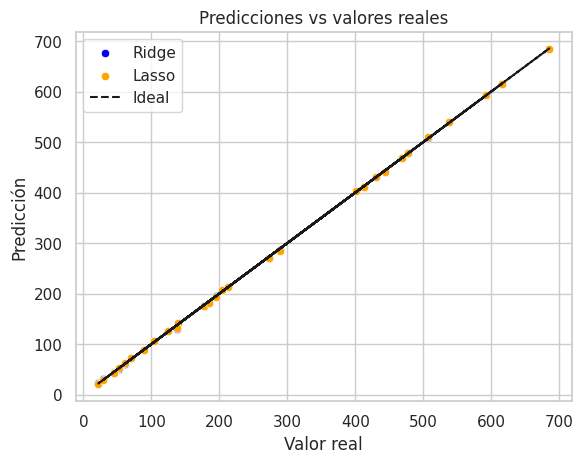

In [13]:
sns.scatterplot(x=y_test, y=ridge.predict(X_test), label='Ridge', color='blue')
sns.scatterplot(x=y_test, y=lasso.predict(X_test), label='Lasso', color='orange')
plt.plot(y_test, y_test, 'k--', label='Ideal')
plt.xlabel("Valor real")
plt.ylabel("Predicción")
plt.legend()
plt.title("Predicciones vs valores reales")
plt.show()


# 📊 Explicación

Los puntos de ambos modelos estarán cerca de la línea diagonal,
lo que indica predicciones consistentes y buena capacidad de generalización.

# 📌 **Conclusión clara**

Los tres modelos funcionan casi igual de bien,
pero Ridge ofrece el mejor equilibrio entre precisión y estabilidad.

Lasso es útil si se busca simplificar el modelo (reducir variables),
mientras que Ridge es mejor para mantener el rendimiento sin riesgo de inestabilidad.

En este caso, como los datos tienen una relación muy limpia,
las diferencias son mínimas, pero en datos reales con más ruido,
Ridge y Lasso ayudan a evitar el sobreajuste.

# 🔧 **13. Paso adicional (opcional): Preparar los datos para la regresión con regularización (Ridge y Lasso)**

Este paso no reemplaza nada de lo anterior.  
Solo muestra cómo **preparar correctamente un conjunto de datos completo** (con variables categóricas y numéricas) antes de aplicar Ridge y Lasso.

---

### 🧩 Objetivo del paso
1. Codificar variables categóricas (`clima`, `frenos_abs`) con **One Hot Encoding**.  
2. Separar las variables independientes (X) y la dependiente (y).  
3. Dividir el dataset en **entrenamiento y prueba**.  
4. Escalar los valores para que todas las variables tengan el mismo peso en el modelo.



In [14]:
# Paso 13: Preparar los datos para la regresión con regularización (Ridge y Lasso)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# A. Codificación de variables categóricas
df_encoded = pd.get_dummies(data, columns=["clima"], drop_first=True) # <----- ¿Que hace esta linea de codigo?

# B. Separar variables independientes y dependiente
X = df_encoded.drop(columns="distancia")
y = df_encoded["distancia"]

# C. Dividir en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# D. Escalado de características
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Datos listos para Ridge y Lasso")
print(f"X_train_scaled: {X_train_scaled.shape}, X_test_scaled: {X_test_scaled.shape}")

Datos listos para Ridge y Lasso
X_train_scaled: (80, 6), X_test_scaled: (20, 6)


# 🧠 2. Qué hizo realmente get_dummies()

* Transformó la variable categórica “clima” en varias columnas binarias (0 y 1).

* Cada columna nueva representa una categoría posible:

* clima_nublado = 1 si el clima fue “nublado”.

* clima_lluvioso = 1 si el clima fue “lluvioso”.

No se crea clima_soleado porque usamos drop_first=True → eso evita redundancia estadística (lo toma como categoría base).

En otras palabras: si ambas columnas están en 0, significa “soleado”.

In [15]:
# 👀 Verificar el nuevo DataFrame después del One Hot Encoding
data.head()

,velocidad,distancia,ruido_sensor,clima,frenos_abs,carga_vehiculo
0,20.000000,21.926957,1.490142,soleado,1,436.814880
1,21.010101,22.362952,-0.414793,nublado,1,706.527884
2,22.020202,26.945541,1.943066,soleado,0,758.010101
3,23.030303,31.331082,4.569090,soleado,0,242.249679
4,24.040404,28.519942,-0.702460,lluvioso,0,325.351231


In [16]:
# 👀 Verificar el nuevo DataFrame después del One Hot Encoding
#df_encoded.info()
df_encoded.head()

,velocidad,distancia,ruido_sensor,frenos_abs,carga_vehiculo,clima_nublado,clima_soleado
0,20.000000,21.926957,1.490142,1,436.814880,False,True
1,21.010101,22.362952,-0.414793,1,706.527884,True,False
2,22.020202,26.945541,1.943066,0,758.010101,False,True
3,23.030303,31.331082,4.569090,0,242.249679,False,True
4,24.040404,28.519942,-0.702460,0,325.351231,False,False


In [17]:
# Ver los estados únicos de la columna 'clima' en el DataFrame original
data['clima'].unique()


array(['soleado', 'nublado', 'lluvioso'], dtype=object)

In [18]:
# Ver los estados únicos de la columna 'clima' en el DataFrame original
data['clima'].value_counts()

,count
clima,
lluvioso,36
soleado,34
nublado,30


# **🧠 Conclusión**

Este bloque prepara los datos de forma profesional para aplicar regularización.
Si decides usarlo más adelante:

Solo sustituye **X_train** y **X_test** por **X_train_scaled** y **X_test_scaled** en tus modelos Ridge y Lasso.

El resto de tu notebook no se toca.

# 🚀 **Conclusión final**

Dominar la regresión te enseña mucho más que ajustar curvas: Te enseña a pensar con datos, a cuestionar resultados y a construir modelos que sean tanto precisos como éticos.

Has desarrollado las bases para avanzar hacia técnicas más sofisticadas como: Árboles, Bosques de desición o Redes Neuronales con la mentalidad analítica y crítica que distingue a un verdadero científico de datos.

Recuerda: No se trata solo de predecir con exactitud, sino de entender por qué el modelo predice lo que predice.

Esa es la diferencia entre un técnico y un analista con criterio.